In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('breast-cancer.csv')
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [8]:
data.isnull().count()
data.duplicated().count()

np.int64(569)

<Axes: >

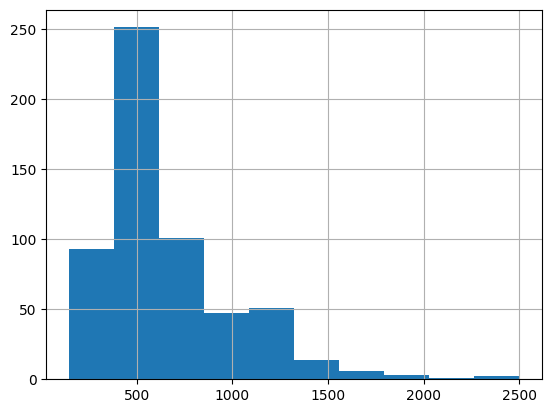

In [9]:
data['area_mean'].hist()

<Axes: >

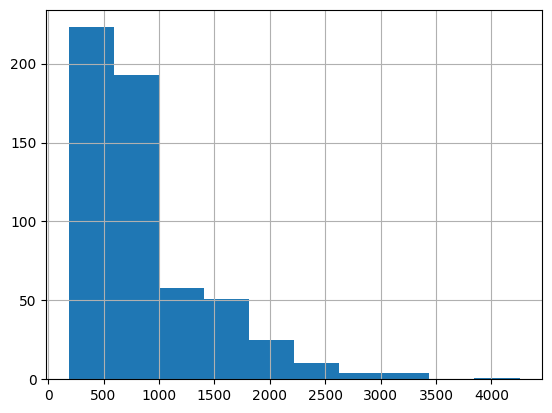

In [10]:
data['area_worst'].hist()

<Axes: >

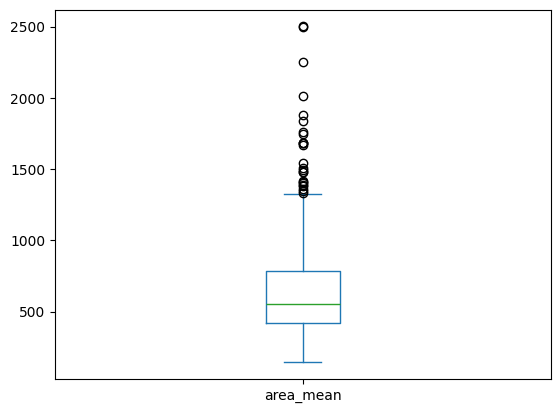

In [14]:
data['area_mean'].plot(kind = 'box')

<Axes: >

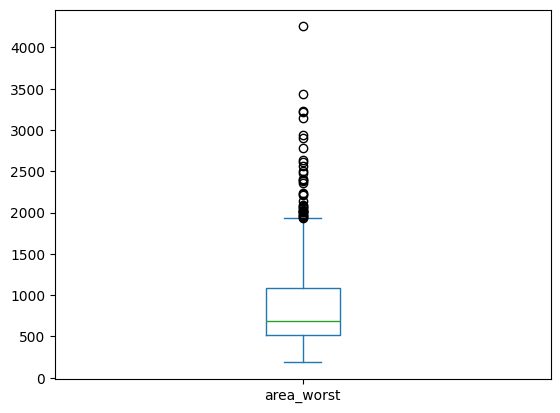

In [15]:
data['area_worst'].plot(kind = 'box')

# Train Test Split

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(data.drop('diagnosis', axis = 1),
                                                              data['diagnosis'],
                                                              test_size = 0.3,
                                                              random_state = 0)
X_train.shape, X_test.shape

((398, 31), (171, 31))

# MinMaxScaling

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [20]:
np.round(X_train.describe(), 2)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,3.980000e+02,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,...,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00
mean,3.047314e+07,14.19,19.19,92.34,661.86,0.10,0.10,0.09,0.05,0.18,...,16.36,25.53,107.74,894.25,0.13,0.25,0.27,0.12,0.29,0.08
std,1.275650e+08,3.60,4.19,24.77,366.56,0.01,0.05,0.08,0.04,0.03,...,4.97,6.15,34.46,597.85,0.02,0.15,0.19,0.07,0.06,0.02
min,8.670000e+03,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,8.657155e+05,11.71,16.03,75.31,420.35,0.09,0.07,0.03,0.02,0.16,...,13.05,20.86,84.12,516.42,0.12,0.15,0.12,0.07,0.25,0.07
50%,9.055015e+05,13.31,18.73,86.14,548.45,0.10,0.09,0.06,0.03,0.18,...,14.92,25.16,97.46,682.00,0.13,0.22,0.23,0.10,0.28,0.08
75%,8.811826e+06,15.77,21.60,104.48,779.12,0.11,0.13,0.13,0.08,0.20,...,19.00,29.45,125.78,1093.25,0.15,0.33,0.38,0.16,0.32,0.09
max,9.113205e+08,28.11,33.81,188.50,2501.00,0.14,0.31,0.43,0.20,0.30,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.10,0.29,0.66,0.21


In [21]:
np.round(X_train_scaled.describe(), 2)

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,...,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00,398.00
mean,0.03,0.34,0.39,0.34,0.22,0.48,0.29,0.21,0.25,0.38,...,0.30,0.36,0.29,0.17,0.41,0.22,0.24,0.40,0.26,0.19
std,0.14,0.17,0.17,0.17,0.16,0.15,0.17,0.18,0.19,0.14,...,0.18,0.16,0.17,0.15,0.15,0.15,0.17,0.23,0.13,0.12
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.22,0.26,0.22,0.12,0.37,0.16,0.07,0.10,0.28,...,0.18,0.24,0.17,0.08,0.30,0.12,0.11,0.23,0.18,0.11
50%,0.00,0.30,0.37,0.29,0.17,0.47,0.26,0.15,0.17,0.37,...,0.25,0.35,0.23,0.12,0.40,0.18,0.21,0.34,0.25,0.16
75%,0.01,0.42,0.49,0.42,0.27,0.57,0.37,0.30,0.37,0.45,...,0.39,0.46,0.38,0.22,0.49,0.29,0.34,0.56,0.32,0.24
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


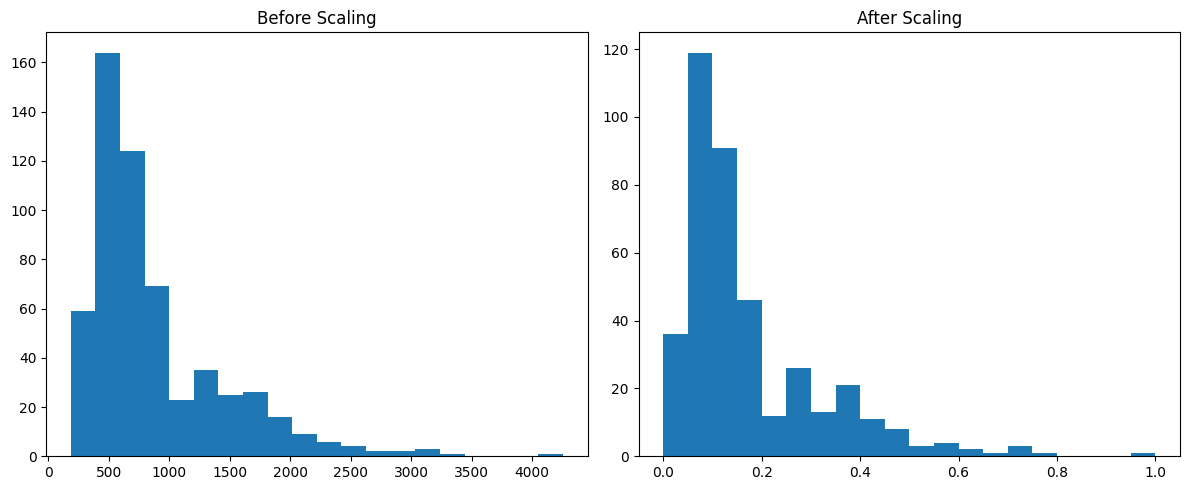

In [22]:
import matplotlib.pyplot as plt

feature = 'area_worst'

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(data[feature], bins=20)
plt.title("Before Scaling")

plt.subplot(1,2,2)
plt.hist(X_train_scaled[feature], bins=20)
plt.title("After Scaling")

plt.tight_layout()
plt.show()

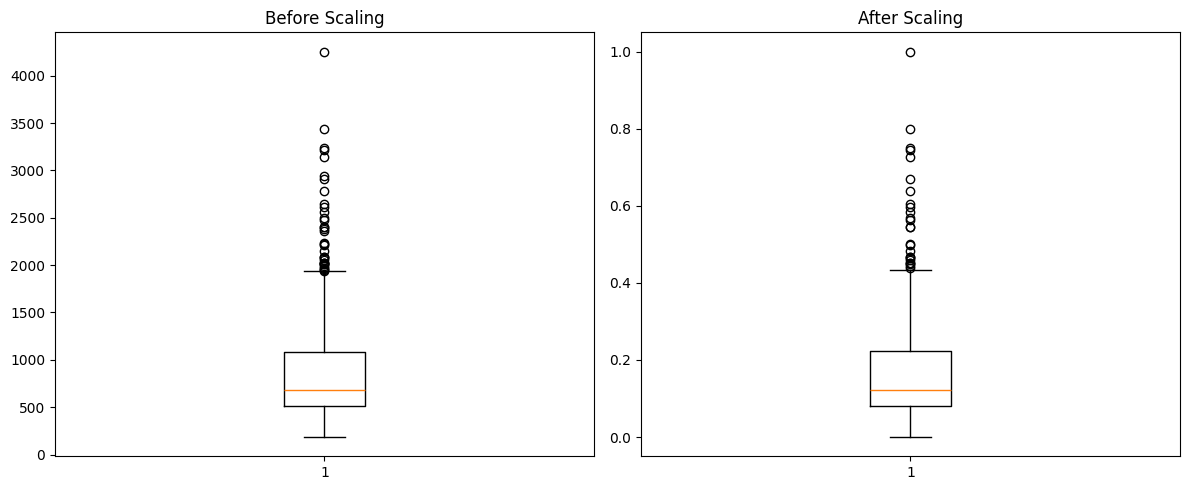

In [23]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.boxplot(data[feature])
plt.title("Before Scaling")

plt.subplot(1,2,2)
plt.boxplot(X_train_scaled[feature])
plt.title("After Scaling")

plt.tight_layout()
plt.show()

In [24]:
print("Before Scaling:")
print("Mean:", data[feature].mean())
print("Std:", data[feature].std())

print("\nAfter Scaling:")
print("Mean:", X_train_scaled[feature].mean())
print("Std:", X_train_scaled[feature].std())

Before Scaling:
Mean: 880.5831282952548
Std: 569.3569926699492

After Scaling:
Mean: 0.17426439857565448
Std: 0.1469361684216134
